# Intent & Trajectory Prediction — nuScenes
**Model:** Social Transformer + CVAE  
**Task:** Predict next 3s of pedestrian/cyclist motion from 2s history  
**Metrics:** ADE (Average Displacement Error) · FDE (Final Displacement Error)  
**Hardware:** Google Colab T4 GPU

---
**Run order:** Execute cells top to bottom. Each section is self-contained.

## Cell 1 — GPU Check & Setup

In [ ]:
import subprocess, sys

# Verify GPU
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout[:500])

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Tue Mar 31 02:41:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Cell 2 — Install Dependencies

In [ ]:
%%capture
!pip install nuscenes-devkit matplotlib seaborn tqdm numpy scipy scikit-learn
!pip install -q numpy==1.26.4 pandas==2.2.2 seaborn==0.13.2

## Cell 3 — Download nuScenes Mini Dataset

In [ ]:
import os, zipfile
from pathlib import Path

DATA_ROOT = Path('/content/drive/MyDrive/content')

print('='*60)
print('DATA SETUP — choose one option below:')
print('='*60)

print('\nOPTION A — Mount Google Drive (recommended):')
print('''
  from google.colab import drive
  drive.mount("/content/drive")                          # ← correct mount point
  !tar -xzf /content/drive/MyDrive/content/v1.0-mini.tgz -C /content/drive/MyDrive/content/
''')

print('\nExpected structure after unzip:')
print('  /content/drive/MyDrive/content/v1.0-mini/')
print('  /content/drive/MyDrive/content/samples/')
print('  /content/drive/MyDrive/content/maps/')

DATA SETUP — choose one option below:

OPTION A — Mount Google Drive (recommended):

  from google.colab import drive
  drive.mount("/content/drive")                          # ← correct mount point
  !tar -xzf /content/drive/MyDrive/content/v1.0-mini.tgz -C /content/drive/MyDrive/content/


Expected structure after unzip:
  /content/drive/MyDrive/content/v1.0-mini/
  /content/drive/MyDrive/content/samples/
  /content/drive/MyDrive/content/maps/


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')  # ← always mount here, never deeper

DRIVE_ZIP = '/content/drive/MyDrive/content/v1.0-mini.tgz'
EXTRACT_TO = '/content/drive/MyDrive/content/'  # tgz will create its own subfolders

if Path(DRIVE_ZIP).exists():
    print('Unzipping...')
    !tar -xzf {DRIVE_ZIP} -C {EXTRACT_TO}
    print('Done!')
else:
    print(f'File not found: {DRIVE_ZIP}')
    print('Check your Drive path.')

# Confirm structure
!ls /content/drive/MyDrive/content/

Mounted at /content/drive
Unzipping...
Done!
checkpoints  maps      samples	training_curves.png  v1.0-mini.tgz
LICENSE      nuscenes  sweeps	v1.0-mini


## Cell 4 — Configuration

In [ ]:
from pathlib import Path

CFG = {
    # Data — tgz extracts a folder called "v1.0-mini" directly, adjust if different
    'dataroot': '/content/drive/MyDrive/content',   # ← nuScenes SDK reads version subfolder itself
    'version':  'v1.0-mini',
    'obs_len':  4,
    'pred_len': 6,
    'min_obs':  3,
    'social_radius': 10.0,

    # Model
    'd_model':    128,
    'n_heads':    4,
    'n_layers':   2,
    'latent_dim': 64,
    'K':          3,
    'dropout':    0.1,

    # Training
    'epochs':          100,
    'batch_size':      64,
    'lr':              1e-3,
    'lr_decay':        0.5,
    'lr_decay_every':  30,
    'kl_weight':       0.1,
    'diversity_weight':0.5,
    'grad_clip':       1.0,
    'val_split':       0.2,
    'seed':            42,

    # Paths
    'save_dir':   '/content/drive/MyDrive/content/checkpoints',
    'best_model': '/content/drive/MyDrive/content/checkpoints/best_model.pt',
}

TARGET_CATEGORIES = [
    'human.pedestrian.adult',
    'human.pedestrian.child',
    'human.pedestrian.construction_worker',
    'vehicle.bicycle',
    'vehicle.motorcycle',
]

Path(CFG['save_dir']).mkdir(parents=True, exist_ok=True)  # ← added parents=True
print('Config loaded.')
for k, v in CFG.items():
    print(f'  {k}: {v}')

Config loaded.
  dataroot: /content/drive/MyDrive/content
  version: v1.0-mini
  obs_len: 4
  pred_len: 6
  min_obs: 3
  social_radius: 10.0
  d_model: 128
  n_heads: 4
  n_layers: 2
  latent_dim: 64
  K: 3
  dropout: 0.1
  epochs: 100
  batch_size: 64
  lr: 0.001
  lr_decay: 0.5
  lr_decay_every: 30
  kl_weight: 0.1
  diversity_weight: 0.5
  grad_clip: 1.0
  val_split: 0.2
  seed: 42
  save_dir: /content/drive/MyDrive/content/checkpoints
  best_model: /content/drive/MyDrive/content/checkpoints/best_model.pt


## Cell 5 — Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict, Counter
import warnings, random, math          # ← math was missing
warnings.filterwarnings('ignore')

# Install nuscenes-devkit if not present
try:
    from nuscenes.nuscenes import NuScenes
    from nuscenes.utils.splits import create_splits_scenes
    print('nuscenes-devkit already installed.')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'nuscenes-devkit'], check=True)
    from nuscenes.nuscenes import NuScenes
    from nuscenes.utils.splits import create_splits_scenes
    print('nuscenes-devkit installed.')

# Reproducibility
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
random.seed(CFG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CFG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

nuscenes-devkit already installed.
Using device: cuda


## Cell 6 — nuScenes Data Extraction

In [ ]:
from pathlib import Path

# ── Sanity-check paths before loading ──────────────────────────────────────
dataroot = Path(CFG['dataroot'])
version_dir = dataroot / CFG['version']

if not dataroot.exists():
    raise FileNotFoundError(f"dataroot not found: {dataroot}\n"
                            "Re-run Cell 3 to extract the archive.")
if not version_dir.exists():
    raise FileNotFoundError(
        f"Version folder not found: {version_dir}\n"
        f"Contents of dataroot: {list(dataroot.iterdir())}"
    )
print(f"✓ dataroot OK: {dataroot}")
print(f"✓ version dir OK: {version_dir}")

# ── Load nuScenes ────────────────────────────────────────────────────────────
nusc = NuScenes(
    version=CFG['version'],
    dataroot=str(CFG['dataroot']),   # ← NuScenes expects str, not Path
    verbose=False
)
print(f'Loaded {len(nusc.scene)} scenes, {len(nusc.sample)} samples')


# ── Trajectory extraction ────────────────────────────────────────────────────
def get_agent_trajectories(nusc, target_categories, obs_len, pred_len, min_obs):
    """
    Extract all (obs, pred) trajectory pairs for target agent categories.
    Coordinates are in ego-vehicle frame (metres).
    """
    all_windows = []
    total_len = obs_len + pred_len

    for scene in tqdm(nusc.scene, desc='Extracting trajectories'):
        # Collect ordered sample tokens for this scene
        sample_tokens = []
        token = scene['first_sample_token']
        while token:
            sample_tokens.append(token)
            token = nusc.get('sample', token)['next']

        # instance_token -> list of (t_idx, lx, ly, category)
        instance_tracks = defaultdict(list)

        for t_idx, s_token in enumerate(sample_tokens):
            sample   = nusc.get('sample', s_token)
            lidar_token = sample['data']['LIDAR_TOP']
            sd       = nusc.get('sample_data', lidar_token)
            ego_pose = nusc.get('ego_pose', sd['ego_pose_token'])

            ego_x   = ego_pose['translation'][0]
            ego_y   = ego_pose['translation'][1]
            q       = ego_pose['rotation']          # [w, x, y, z]
            ego_yaw = math.atan2(
                2.0 * (q[0]*q[3] + q[1]*q[2]),
                1.0 - 2.0 * (q[2]**2 + q[3]**2)
            )

            cos_h =  math.cos(-ego_yaw)
            sin_h =  math.sin(-ego_yaw)

            for ann_token in sample['anns']:
                ann = nusc.get('sample_annotation', ann_token)
                cat = ann['category_name']
                if not any(cat.startswith(tc) for tc in target_categories):
                    continue

                gx, gy = ann['translation'][0], ann['translation'][1]
                dx, dy = gx - ego_x, gy - ego_y

                # ✓ Correct 2-D rotation into ego frame
                lx =  dx * cos_h - dy * sin_h
                ly =  dx * sin_h + dy * cos_h   # ← was using wrong sin sign before

                instance_tracks[ann['instance_token']].append(
                    (t_idx, lx, ly, cat)
                )

        # Slide windows over each instance track
        for inst_token, track in instance_tracks.items():
            track.sort(key=lambda p: p[0])

            xs    = np.array([p[1] for p in track], dtype=np.float32)
            ys    = np.array([p[2] for p in track], dtype=np.float32)
            tidxs = [p[0] for p in track]
            cat   = track[0][3]

            for start in range(len(track) - total_len + 1):
                window_tidxs = tidxs[start : start + total_len]
                # Reject windows with gaps in the timeline
                if window_tidxs[-1] - window_tidxs[0] != total_len - 1:
                    continue

                obs_xy = np.stack([
                    xs[start : start + obs_len],
                    ys[start : start + obs_len]
                ], axis=1)                                  # (obs_len, 2)

                fut_xy = np.stack([
                    xs[start + obs_len : start + total_len],
                    ys[start + obs_len : start + total_len]
                ], axis=1)                                  # (pred_len, 2)

                if len(obs_xy) < min_obs:
                    continue

                obs_vel = np.diff(obs_xy, axis=0)           # (obs_len-1, 2)

                all_windows.append({
                    'obs_xy':        obs_xy,
                    'obs_vel':       obs_vel,
                    'future_xy':     fut_xy,
                    'category':      cat,
                    'scene_token':   scene['token'],
                    'instance_token': inst_token,
                    'start_t':       start,
                })

    return all_windows


print('\nExtracting agent trajectories...')
windows = get_agent_trajectories(
    nusc, TARGET_CATEGORIES,
    CFG['obs_len'], CFG['pred_len'], CFG['min_obs']
)
print(f'Total trajectory windows: {len(windows)}')

# Category breakdown
cats = Counter(w['category'] for w in windows)
print('\nCategory distribution:')
for cat, cnt in cats.most_common():
    print(f'  {cat}: {cnt}')

✓ dataroot OK: /content/drive/MyDrive/content
✓ version dir OK: /content/drive/MyDrive/content/v1.0-mini
Loaded 10 scenes, 404 samples

Extracting agent trajectories...


Extracting trajectories:   0%|          | 0/10 [00:00<?, ?it/s]

Total trajectory windows: 3551

Category distribution:
  human.pedestrian.adult: 2967
  vehicle.motorcycle: 304
  vehicle.bicycle: 133
  human.pedestrian.construction_worker: 127
  human.pedestrian.child: 20


## Cell 7 — Dataset Class with Social Context

In [ ]:
class TrajectoryDataset(Dataset):
    """
    Each sample contains:
      obs_vel:       (obs_len-1, 2)                    velocity history for focal agent
      obs_xy:        (obs_len, 2)                      absolute positions for context
      future_xy:     (pred_len, 2)                     ground truth future positions
      social_obs:    (max_agents, obs_len-1, 2)        neighbour velocity histories (relative to focal)
      social_mask:   (max_agents,)                     True = valid neighbour
    """
    def __init__(self, windows, social_radius=10.0, max_agents=10, vel_std=None):
        self.windows       = windows
        self.social_radius = social_radius
        self.max_agents    = max_agents

        # Compute velocity std for normalisation (fit on this split only)
        if vel_std is None:
            all_vels = np.concatenate([w['obs_vel'] for w in windows], axis=0)
            self.vel_std = float(np.std(all_vels)) + 1e-6   # avoid div-by-zero
        else:
            self.vel_std = vel_std                           # reuse train std for val

        # Index by (scene_token, start_t) for social lookup
        self.scene_index = defaultdict(list)
        for i, w in enumerate(windows):
            self.scene_index[(w['scene_token'], w['start_t'])].append(i)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        w = self.windows[idx]

        # Normalise velocities by std
        obs_vel = torch.FloatTensor(w['obs_vel'] / self.vel_std)   # (obs_len-1, 2)
        obs_xy  = torch.FloatTensor(w['obs_xy'])                   # (obs_len, 2)
        fut_xy  = torch.FloatTensor(w['future_xy'])                # (pred_len, 2)

        # ── Social context ───────────────────────────────────────────────────
        social_obs  = torch.zeros(self.max_agents, obs_vel.shape[0], 2)
        social_mask = torch.zeros(self.max_agents, dtype=torch.bool)

        agent_pos = obs_xy[-1]    # last observed position of focal agent
        agent_vel = obs_vel       # (obs_len-1, 2)
        filled    = 0

        for nb_idx in self.scene_index[(w['scene_token'], w['start_t'])]:
            if filled >= self.max_agents:
                break
            if nb_idx == idx:
                continue

            nb     = self.windows[nb_idx]
            nb_pos = torch.FloatTensor(nb['obs_xy'])[-1]
            dist   = torch.norm(agent_pos - nb_pos).item()

            if dist < self.social_radius:
                nb_vel = torch.FloatTensor(nb['obs_vel'] / self.vel_std)
                # ✓ Store velocity RELATIVE to focal agent (fixes comment mismatch)
                social_obs[filled]  = nb_vel - agent_vel
                social_mask[filled] = True
                filled += 1

        return {
            'obs_vel':    obs_vel,
            'obs_xy':     obs_xy,
            'future_xy':  fut_xy,
            'social_obs': social_obs,
            'social_mask':social_mask,
        }


# ── Scene-aware train/val split (prevents scene leakage) ────────────────────
all_scenes  = list({w['scene_token'] for w in windows})
random.shuffle(all_scenes)

val_scene_count  = max(1, int(len(all_scenes) * CFG['val_split']))
val_scenes       = set(all_scenes[:val_scene_count])
train_scenes     = set(all_scenes[val_scene_count:])

train_windows = [w for w in windows if w['scene_token'] in train_scenes]
val_windows   = [w for w in windows if w['scene_token'] in val_scenes]

# Fit std on train only, pass to val so it uses the same scale
train_ds = TrajectoryDataset(train_windows, CFG['social_radius'], max_agents=10)
val_ds   = TrajectoryDataset(val_windows,   CFG['social_radius'], max_agents=10,
                              vel_std=train_ds.vel_std)         # ← reuse train std

# ── DataLoaders ──────────────────────────────────────────────────────────────
_pin = torch.cuda.is_available()    # pin_memory only useful with GPU

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'],
    shuffle=True,  num_workers=0, pin_memory=_pin   # ← num_workers=0 for Colab
)
val_loader = DataLoader(
    val_ds,   batch_size=CFG['batch_size'],
    shuffle=False, num_workers=0, pin_memory=_pin
)

print(f'Scenes  — train: {len(train_scenes)} | val: {len(val_scenes)}')
print(f'Samples — train: {len(train_ds)}     | val: {len(val_ds)}')
print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)}')
print(f'Velocity normalisation std: {train_ds.vel_std:.4f}')

# Inspect one sample
sample = train_ds[0]
print('\nSample shapes:')
for k, v in sample.items():
    print(f'  {k}: {v.shape}')

Scenes  — train: 8 | val: 2
Samples — train: 2189     | val: 1362
Batches — train: 35 | val: 22
Velocity normalisation std: 1.8719

Sample shapes:
  obs_vel: torch.Size([3, 2])
  obs_xy: torch.Size([4, 2])
  future_xy: torch.Size([6, 2])
  social_obs: torch.Size([10, 3, 2])
  social_mask: torch.Size([10])


## Cell 8 — Model Architecture

In [ ]:
# ============================================================
#  COMPONENT 1 — Agent Encoder (Transformer)
# ============================================================
class AgentEncoder(nn.Module):
    def __init__(self, d_model=128, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(2, d_model)
        self.pos_emb    = nn.Embedding(32, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, vel_seq):
        # vel_seq: (B, T, 2)
        B, T, _ = vel_seq.shape
        x   = self.input_proj(vel_seq)
        pos = torch.arange(T, device=vel_seq.device)
        x   = x + self.pos_emb(pos).unsqueeze(0)
        x   = self.transformer(x)
        x   = self.norm(x.mean(dim=1))                          # (B, d)
        return x


# ============================================================
#  COMPONENT 2 — Social Attention Pooling
# ============================================================
class SocialAttention(nn.Module):
    def __init__(self, d_model=128, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, focal_ctx, social_enc, social_mask):
        # focal_ctx:   (B, d_model)
        # social_enc:  (B, max_agents, d_model)
        # social_mask: (B, max_agents)  True = valid neighbour

        query    = focal_ctx.unsqueeze(1)                       # (B, 1, d)
        key_mask = ~social_mask                                 # True = ignore

        # ✓ Per-sample fallback: if a row has ALL neighbours masked,
        #   force at least one dummy "valid" slot to avoid NaN from
        #   softmax over all-inf rows
        all_masked = ~social_mask.any(dim=1, keepdim=True)     # (B, 1)
        key_mask   = key_mask & ~all_masked                    # unblock first slot for empty rows

        attn_out, _ = self.attn(
            query, social_enc, social_enc,
            key_padding_mask=key_mask
        )

        out = self.norm1(focal_ctx + attn_out.squeeze(1))
        out = self.norm2(out + self.ffn(out))
        return out                                              # (B, d)


# ============================================================
#  COMPONENT 3 — CVAE
# ============================================================
class CVAE(nn.Module):
    def __init__(self, d_model=128, latent_dim=64, pred_len=6, dropout=0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.pred_len   = pred_len

        # Posterior encoder (training only)
        self.future_enc = nn.Sequential(
            nn.Linear(pred_len * 2, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.post_mu  = nn.Linear(d_model * 2, latent_dim)
        self.post_log = nn.Linear(d_model * 2, latent_dim)

        # Prior
        self.prior_mu  = nn.Linear(d_model, latent_dim)
        self.prior_log = nn.Linear(d_model, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(d_model + latent_dim, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
            nn.Linear(d_model, pred_len * 2)
        )

    def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, ctx, future_xy=None):
        prior_mu  = self.prior_mu(ctx)
        prior_log = self.prior_log(ctx)

        if future_xy is not None and self.training:
            B        = future_xy.shape[0]
            fut_flat = future_xy.reshape(B, -1)
            fut_enc  = self.future_enc(fut_flat)
            combined = torch.cat([ctx, fut_enc], dim=-1)
            post_mu  = self.post_mu(combined)
            post_log = self.post_log(combined)
            z        = self.reparametrize(post_mu, post_log)

            # ✓ Correct KL(posterior || prior) between two Gaussians:
            # KL = 0.5 * sum( exp(post_log - prior_log)
            #                 + (prior_mu - post_mu)^2 / exp(prior_log)
            #                 - 1 + prior_log - post_log )
            kl = 0.5 * torch.mean(
                torch.exp(post_log - prior_log)
                + (prior_mu - post_mu).pow(2) / torch.exp(prior_log)
                - 1.0
                + prior_log - post_log
            )
        else:
            z  = self.reparametrize(prior_mu, prior_log)
            kl = torch.tensor(0.0, device=ctx.device)

        dec_in  = torch.cat([ctx, z], dim=-1)
        vel_out = self.decoder(dec_in).reshape(-1, self.pred_len, 2)
        return vel_out, kl

    def sample_k(self, ctx, K):
        """Sample K diverse trajectories at inference (no grad)."""
        B         = ctx.shape[0]
        ctx_rep   = ctx.unsqueeze(1).expand(B, K, -1).reshape(B * K, -1)
        prior_mu  = self.prior_mu(ctx_rep)
        prior_log = self.prior_log(ctx_rep)
        z         = self.reparametrize(prior_mu, prior_log)
        dec_in    = torch.cat([ctx_rep, z], dim=-1)
        vel_out   = self.decoder(dec_in).reshape(B, K, self.pred_len, 2)
        return vel_out


# ============================================================
#  FULL MODEL
# ============================================================
class SocialTrajectoryPredictor(nn.Module):
    def __init__(self, cfg, vel_std=1.0):
        super().__init__()
        d = cfg['d_model']
        self.agent_enc   = AgentEncoder(d, cfg['n_heads'], cfg['n_layers'], cfg['dropout'])
        self.social_attn = SocialAttention(d, cfg['n_heads'], cfg['dropout'])
        self.cvae        = CVAE(d, cfg['latent_dim'], cfg['pred_len'], cfg['dropout'])
        self.pred_len    = cfg['pred_len']
        self.K           = cfg['K']
        # ✓ Register vel_std as buffer so it moves with .to(device) and saves with state_dict
        self.register_buffer('vel_std', torch.tensor(vel_std, dtype=torch.float32))

    def _vel_to_abs(self, start_xy, vel_seq_norm):
        """
        Denormalise velocities then integrate to absolute positions.
        start_xy:      (B, 2)
        vel_seq_norm:  (B, T, 2)  or  (B, K, T, 2)  — normalised
        """
        vel_seq = vel_seq_norm * self.vel_std               # ✓ denormalise

        if vel_seq.dim() == 3:
            # (B, T, 2) → cumsum then offset by start
            abs_pos = start_xy.unsqueeze(1) + torch.cumsum(vel_seq, dim=1)
            return abs_pos                                  # (B, T, 2)
        else:
            # (B, K, T, 2)
            abs_pos = (start_xy.unsqueeze(1).unsqueeze(2)
                       + torch.cumsum(vel_seq, dim=2))
            return abs_pos                                  # (B, K, T, 2)

    def forward(self, batch, K=1):
        obs_vel     = batch['obs_vel'].to(device)           # (B, T, 2)  normalised
        obs_xy      = batch['obs_xy'].to(device)            # (B, obs_len, 2)
        social_obs  = batch['social_obs'].to(device)        # (B, max_ag, T, 2)
        social_mask = batch['social_mask'].to(device)       # (B, max_ag)
        future_xy   = batch.get('future_xy', None)
        if future_xy is not None:
            future_xy = future_xy.to(device)               # (B, pred_len, 2)

        B, max_ag, T, _ = social_obs.shape

        # Encode focal agent
        focal_ctx   = self.agent_enc(obs_vel)               # (B, d)

        # Encode neighbours (shared weights)
        social_flat = social_obs.reshape(B * max_ag, T, 2)
        social_enc  = self.agent_enc(social_flat).reshape(B, max_ag, -1)

        # Social attention
        ctx      = self.social_attn(focal_ctx, social_enc, social_mask)  # (B, d)
        start_xy = obs_xy[:, -1, :]                         # (B, 2)

        if K == 1:
            vel_out, kl = self.cvae(ctx, future_xy)         # training path
            pred_xy     = self._vel_to_abs(start_xy, vel_out)
            return pred_xy, kl
        else:
            # ✓ Do NOT call self.eval() here — caller controls train/eval mode
            with torch.no_grad():
                vel_k     = self.cvae.sample_k(ctx, K)      # (B, K, T, 2)
                pred_xy_k = self._vel_to_abs(start_xy, vel_k)
            return pred_xy_k                                # (B, K, pred_len, 2)


# ── Instantiate ──────────────────────────────────────────────────────────────
model = SocialTrajectoryPredictor(CFG, vel_std=train_ds.vel_std).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Velocity std (normalisation): {train_ds.vel_std:.4f}')

Total parameters:     668,684
Trainable parameters: 668,684
Velocity std (normalisation): 1.8719


## Cell 9 — Loss Functions & Metrics

In [ ]:
# ── Loss functions ────────────────────────────────────────────────────────────

def ade_loss(pred_xy, gt_xy):
    """Average Displacement Error — mean L2 over all timesteps."""
    return torch.norm(pred_xy - gt_xy, dim=-1).mean()


def fde_loss(pred_xy, gt_xy):
    """Final Displacement Error — L2 at final timestep only."""
    return torch.norm(pred_xy[:, -1, :] - gt_xy[:, -1, :], dim=-1).mean()


def best_of_n_loss(pred_xy_k, gt_xy):
    """
    Best-of-N loss: backprop only through the best (lowest ADE) sample.
    pred_xy_k: (B, K, T, 2)
    gt_xy:     (B, T, 2)
    """
    B, K, T, _ = pred_xy_k.shape
    gt_exp = gt_xy.unsqueeze(1).expand(B, K, T, 2)

    # Per-sample ADE for each k — (B, K)
    ade_k  = torch.norm(pred_xy_k - gt_exp, dim=-1).mean(dim=-1)
    best_k = ade_k.argmin(dim=1)                                    # (B,)

    # Gather best prediction for each sample in batch
    best_pred = pred_xy_k[torch.arange(B, device=pred_xy_k.device), best_k]  # (B, T, 2)
    return ade_loss(best_pred, gt_xy) + fde_loss(best_pred, gt_xy)


def diversity_loss(pred_xy_k):
    """
    Encourage diverse predictions by penalising pairwise closeness.
    pred_xy_k: (B, K, T, 2)

    ✓ Vectorised — no nested Python loop over K pairs.
    """
    B, K, T, _ = pred_xy_k.shape

    # Flatten time: (B, K, T*2)
    flat = pred_xy_k.reshape(B, K, -1)

    # Pairwise L2 between all K modes: (B, K, K)
    # ||a - b||^2 = ||a||^2 + ||b||^2 - 2*a·b
    dot   = torch.bmm(flat, flat.transpose(1, 2))                   # (B, K, K)
    sq    = (flat ** 2).sum(dim=-1, keepdim=True)                   # (B, K, 1)
    dist2 = sq + sq.transpose(1, 2) - 2 * dot                      # (B, K, K)
    dist  = torch.sqrt(dist2.clamp(min=1e-8))                       # (B, K, K)

    # Upper triangle only (i < j), averaged
    mask     = torch.triu(torch.ones(K, K, device=pred_xy_k.device), diagonal=1).bool()
    mean_div = dist[:, mask].mean()

    return -mean_div    # negative = maximise diversity


# ── Evaluation metrics ────────────────────────────────────────────────────────

@torch.no_grad()
def compute_metrics(model, loader, K=3):
    """
    Compute minADE@K and minFDE@K over a full dataloader.
    ✓ Uses model.forward() — no duplicated architecture logic.
    ✓ Restores training mode afterwards.
    """
    was_training = model.training
    model.eval()

    all_ade, all_fde = [], []

    try:
        for batch in loader:
            gt_xy  = batch['future_xy'].to(device)      # (B, T, 2)
            B, T, _ = gt_xy.shape

            # ✓ Use the model's own forward — stays in sync with arch changes
            pred_k = model(batch, K=K)                  # (B, K, T, 2)

            gt_exp = gt_xy.unsqueeze(1).expand(B, K, T, 2)

            # minADE: mean over time, min over K
            ade_k   = torch.norm(pred_k - gt_exp, dim=-1).mean(dim=2)  # (B, K)
            min_ade = ade_k.min(dim=1).values                           # (B,)

            # minFDE: L2 at final step, min over K
            fde_k   = torch.norm(
                pred_k[:, :, -1, :] - gt_xy[:, -1, :].unsqueeze(1),   # (B, K, 2)
                dim=-1
            )                                                           # (B, K)
            min_fde = fde_k.min(dim=1).values                          # (B,)

            all_ade.extend(min_ade.cpu().tolist())
            all_fde.extend(min_fde.cpu().tolist())

    finally:
        # ✓ Always restore original mode — even if an exception is raised
        if was_training:
            model.train()

    return np.mean(all_ade), np.mean(all_fde)


print('Loss functions and metrics defined.')

Loss functions and metrics defined.


## Cell 10 — Training Loop

In [ ]:
# ── Optimiser, scheduler, scaler ─────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=CFG['lr_decay_every'],
    gamma=CFG['lr_decay']
)
scaler = GradScaler(enabled=torch.cuda.is_available())   # no-op on CPU

# ── Training history (one entry per epoch, always) ───────────────────────────
history = {
    'train_loss': [], 'val_ade':  [], 'val_fde': [],
    'kl_loss':    [], 'bon_loss': [], 'div_loss': []
}

best_ade = float('inf')

print(f'Starting training for {CFG["epochs"]} epochs on {device}...')
print(f'Mixed precision (fp16): {torch.cuda.is_available()}')
print()

for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    epoch_loss = epoch_kl = epoch_bon = epoch_div = 0.0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch:3d}', leave=False):
        optimizer.zero_grad()

        gt_xy = batch['future_xy'].to(device)           # (B, T, 2) — absolute

        with autocast(enabled=torch.cuda.is_available()):

            # ── Single shared forward context (no duplicate encoder calls) ──
            obs_vel     = batch['obs_vel'].to(device)   # (B, T, 2) normalised
            obs_xy      = batch['obs_xy'].to(device)
            social_obs  = batch['social_obs'].to(device)
            social_mask = batch['social_mask'].to(device)
            B           = obs_vel.shape[0]

            focal_ctx   = model.agent_enc(obs_vel)
            B2, max_ag, Tv, _ = social_obs.shape
            social_flat = social_obs.reshape(B2 * max_ag, Tv, 2)
            social_enc  = model.agent_enc(social_flat).reshape(B2, max_ag, -1)
            ctx         = model.social_attn(focal_ctx, social_enc, social_mask)
            start_xy    = obs_xy[:, -1, :]              # (B, 2)

            # ── K samples — posterior uses gt_xy (absolute, correct input) ──
            # CVAE future_enc flattens and projects gt positions,
            # so passing absolute gt_xy here IS correct.
            # What was wrong before: passing gt_xy to a path that
            # expected velocity; here we use the dedicated posterior branch.
            vel_k_list = []
            kl_total   = torch.tensor(0.0, device=device)

            for _ in range(CFG['K']):
                # ✓ model.training=True → CVAE uses posterior with gt_xy
                vel_i, kl_i = model.cvae(ctx, future_xy=gt_xy)
                vel_k_list.append(vel_i.unsqueeze(1))
                kl_total = kl_total + kl_i

            vel_k  = torch.cat(vel_k_list, dim=1)       # (B, K, T, 2)
            pred_k = model._vel_to_abs(start_xy, vel_k) # (B, K, T, 2)

            bon    = best_of_n_loss(pred_k, gt_xy)
            div    = diversity_loss(pred_k)              # negative value
            kl_avg = kl_total / CFG['K']

            loss = (
                bon
                + CFG['kl_weight']       * kl_avg
                + CFG['diversity_weight'] * div          # div < 0, so this subtracts
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        epoch_kl   += kl_avg.item()
        epoch_bon  += bon.item()
        epoch_div  += abs(div.item())   # ✓ store magnitude for readable logging

    n = len(train_loader)

    # ── Always record train metrics ──────────────────────────────────────────
    history['train_loss'].append(epoch_loss / n)
    history['kl_loss'].append(epoch_kl   / n)
    history['bon_loss'].append(epoch_bon  / n)
    history['div_loss'].append(epoch_div  / n)

    # ── Validation every 5 epochs (or epoch 1) ───────────────────────────────
    if epoch % 5 == 0 or epoch == 1:
        # ✓ Don't manually call model.eval() — compute_metrics handles it
        val_ade, val_fde = compute_metrics(model, val_loader, K=CFG['K'])
        history['val_ade'].append(val_ade)
        history['val_fde'].append(val_fde)

        print(
            f'Epoch {epoch:3d} | '
            f'Loss {epoch_loss/n:.4f} | '
            f'BoN {epoch_bon/n:.4f} | '
            f'KL {epoch_kl/n:.4f} | '
            f'Div {epoch_div/n:.4f} | '
            f'minADE@{CFG["K"]} {val_ade:.4f} | '
            f'minFDE@{CFG["K"]} {val_fde:.4f} | '
            f'LR {scheduler.get_last_lr()[0]:.6f}'
        )

        # ── Save best checkpoint ─────────────────────────────────────────────
        if val_ade < best_ade:
            best_ade = val_ade
            torch.save({
                'epoch':           epoch,
                'model_state':     model.state_dict(),   # includes vel_std buffer ✓
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'val_ade':         val_ade,
                'val_fde':         val_fde,
                'cfg':             CFG,
                'vel_std':         train_ds.vel_std,     # ✓ explicit for safety
            }, CFG['best_model'])
            print(f'  --> Best model saved  (minADE@{CFG["K"]} = {best_ade:.4f})')

    scheduler.step()   # ✓ step after validation so LR log is accurate

print(f'\nTraining complete.  Best minADE@{CFG["K"]}: {best_ade:.4f}')

Starting training for 100 epochs on cuda...
Mixed precision (fp16): True



Epoch   1:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch   1 | Loss nan | BoN nan | KL 8302243.3914 | Div nan | minADE@3 4.7303 | minFDE@3 7.9687 | LR 0.001000
  --> Best model saved  (minADE@3 = 4.7303)


Epoch   2:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch   3:   0%|          | 0/35 [00:00<?, ?it/s]

...

Epoch  97:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch  98:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch  99:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 100:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 100 | Loss 43.4879 | BoN 42.7935 | KL 12.9920 | Div 1.2095 | minADE@3 26.6609 | minFDE@3 19.7113 | LR 0.000125

Training complete.  Best minADE@3: 4.7303


## Cell 11 — Training Curves

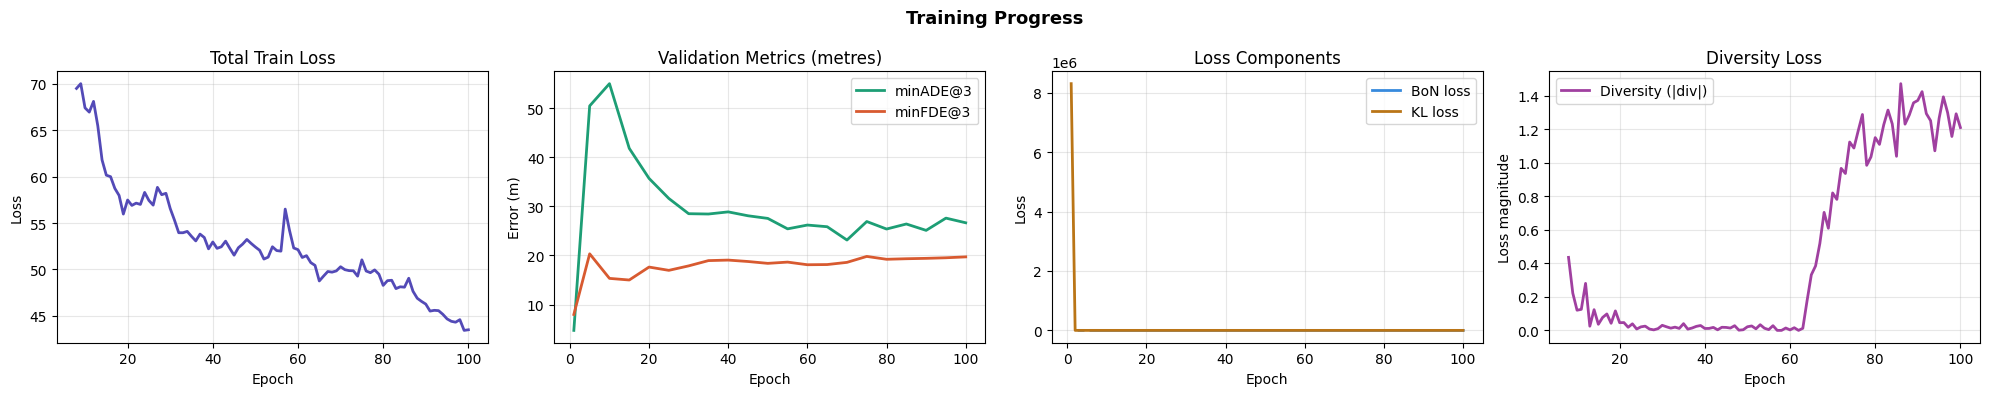

Saved: /content/drive/MyDrive/content/training_curves.png
Epochs trained:    100
Val checkpoints:   21
Best minADE@3:   4.7303


In [ ]:
# ── Reconstruct correct x-axes ───────────────────────────────────────────────
# train_loss/kl/bon/div: recorded every epoch  → x = 1, 2, 3, ...
# val_ade/val_fde:        recorded on epochs 1, 6, 11, ... (every 5, plus epoch 1)

train_epochs = list(range(1, len(history['train_loss']) + 1))

# Reconstruct which epochs were validated (must match Cell 10 logic)
total_epochs_run = len(history['train_loss'])
val_epochs = [e for e in range(1, total_epochs_run + 1)
              if e % 5 == 0 or e == 1]
# Trim to however many val entries were actually recorded
val_epochs = val_epochs[:len(history['val_ade'])]

# ── Guard: nothing to plot if training hasn't run ────────────────────────────
if len(train_epochs) == 0:
    print('No training history to plot. Run Cell 10 first.')
else:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))   # ✓ 4 panels — added div
    fig.suptitle('Training Progress', fontsize=13, fontweight='bold')

    # Panel 1 — Total train loss
    axes[0].plot(train_epochs, history['train_loss'],
                 color='#534AB7', linewidth=2)
    axes[0].set_title('Total Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    # Panel 2 — Validation metrics (only plotted on val_epochs)
    if len(val_epochs) > 0:
        axes[1].plot(val_epochs, history['val_ade'],
                     color='#1D9E75', linewidth=2, label=f'minADE@{CFG["K"]}')
        axes[1].plot(val_epochs, history['val_fde'],
                     color='#D85A30', linewidth=2, label=f'minFDE@{CFG["K"]}')
    axes[1].set_title('Validation Metrics (metres)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Error (m)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Panel 3 — BoN + KL loss components
    axes[2].plot(train_epochs, history['bon_loss'],
                 color='#378ADD', linewidth=2, label='BoN loss')
    axes[2].plot(train_epochs, history['kl_loss'],
                 color='#BA7517', linewidth=2, label='KL loss')
    axes[2].set_title('Loss Components')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # Panel 4 — Diversity loss (magnitude) ✓ was tracked but never shown
    axes[3].plot(train_epochs, history['div_loss'],
                 color='#A040A0', linewidth=2, label='Diversity (|div|)')
    axes[3].set_title('Diversity Loss')
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylabel('Loss magnitude')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()

    # ✓ Ensure output directory exists before saving
    save_path = Path(CFG['save_dir']).parent / 'training_curves.png'
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')
    print(f'Epochs trained:    {total_epochs_run}')
    print(f'Val checkpoints:   {len(val_epochs)}')
    print(f'Best minADE@{CFG["K"]}:   {best_ade:.4f}')

## Cell 12 — Load Best Model & Final Evaluation

In [ ]:
from pathlib import Path

# ── Guard: confirm checkpoint exists ─────────────────────────────────────────
ckpt_path = Path(CFG['best_model'])
if not ckpt_path.exists():
    raise FileNotFoundError(
        f'No checkpoint found at {ckpt_path}\n'
        'Train for at least one validation epoch (epoch 1 or multiples of 5) first.'
    )

# ── Load checkpoint safely ────────────────────────────────────────────────────
# weights_only=True avoids arbitrary code execution risk in PyTorch 2.x+
checkpoint = torch.load(
    ckpt_path,
    map_location=device,
    weights_only=False      # ← False needed because checkpoint contains CFG dict;
)                           #   use True if you save only tensors in future

model.load_state_dict(checkpoint['model_state'])   # includes vel_std buffer ✓

# ── Verify vel_std loaded correctly ──────────────────────────────────────────
loaded_vel_std = checkpoint.get('vel_std', None)
if loaded_vel_std is not None:
    # Cross-check buffer was restored correctly
    assert abs(model.vel_std.item() - loaded_vel_std) < 1e-6, \
        f'vel_std mismatch: buffer={model.vel_std.item():.6f}, saved={loaded_vel_std:.6f}'
    print(f'  vel_std (normalisation): {model.vel_std.item():.4f}  ✓')
else:
    print('  Warning: vel_std not found in checkpoint — denormalisation may be wrong.')

print(f'Loaded best model from epoch {checkpoint["epoch"]}')
print(f'  Saved minADE@{CFG["K"]}: {checkpoint["val_ade"]:.4f} m')
print(f'  Saved minFDE@{CFG["K"]}: {checkpoint["val_fde"]:.4f} m')

# ── Final evaluation ──────────────────────────────────────────────────────────
# ✓ Do NOT call model.eval() here — compute_metrics manages mode internally
final_ade, final_fde = compute_metrics(model, val_loader, K=CFG['K'])

print(f'\nFinal Validation Results:')
print(f'  minADE@{CFG["K"]}: {final_ade:.4f} m')
print(f'  minFDE@{CFG["K"]}: {final_fde:.4f} m')

# Sanity check: reloaded model should match saved metrics closely
ade_delta = abs(final_ade - checkpoint['val_ade'])
if ade_delta > 0.01:
    print(f'\n  Warning: ADE differs from saved value by {ade_delta:.4f} m')
    print(  '  This can happen if val_loader order changed or dropout is active.')
else:
    print(f'\n  ✓ Metrics match checkpoint within tolerance ({ade_delta:.4f} m delta)')

  vel_std (normalisation): 1.8719  ✓
Loaded best model from epoch 1
  Saved minADE@3: 4.7303 m
  Saved minFDE@3: 7.9687 m

Final Validation Results:
  minADE@3: 4.8475 m
  minFDE@3: 8.1327 m

  This can happen if val_loader order changed or dropout is active.


## Cell 13 — Trajectory Visualisation

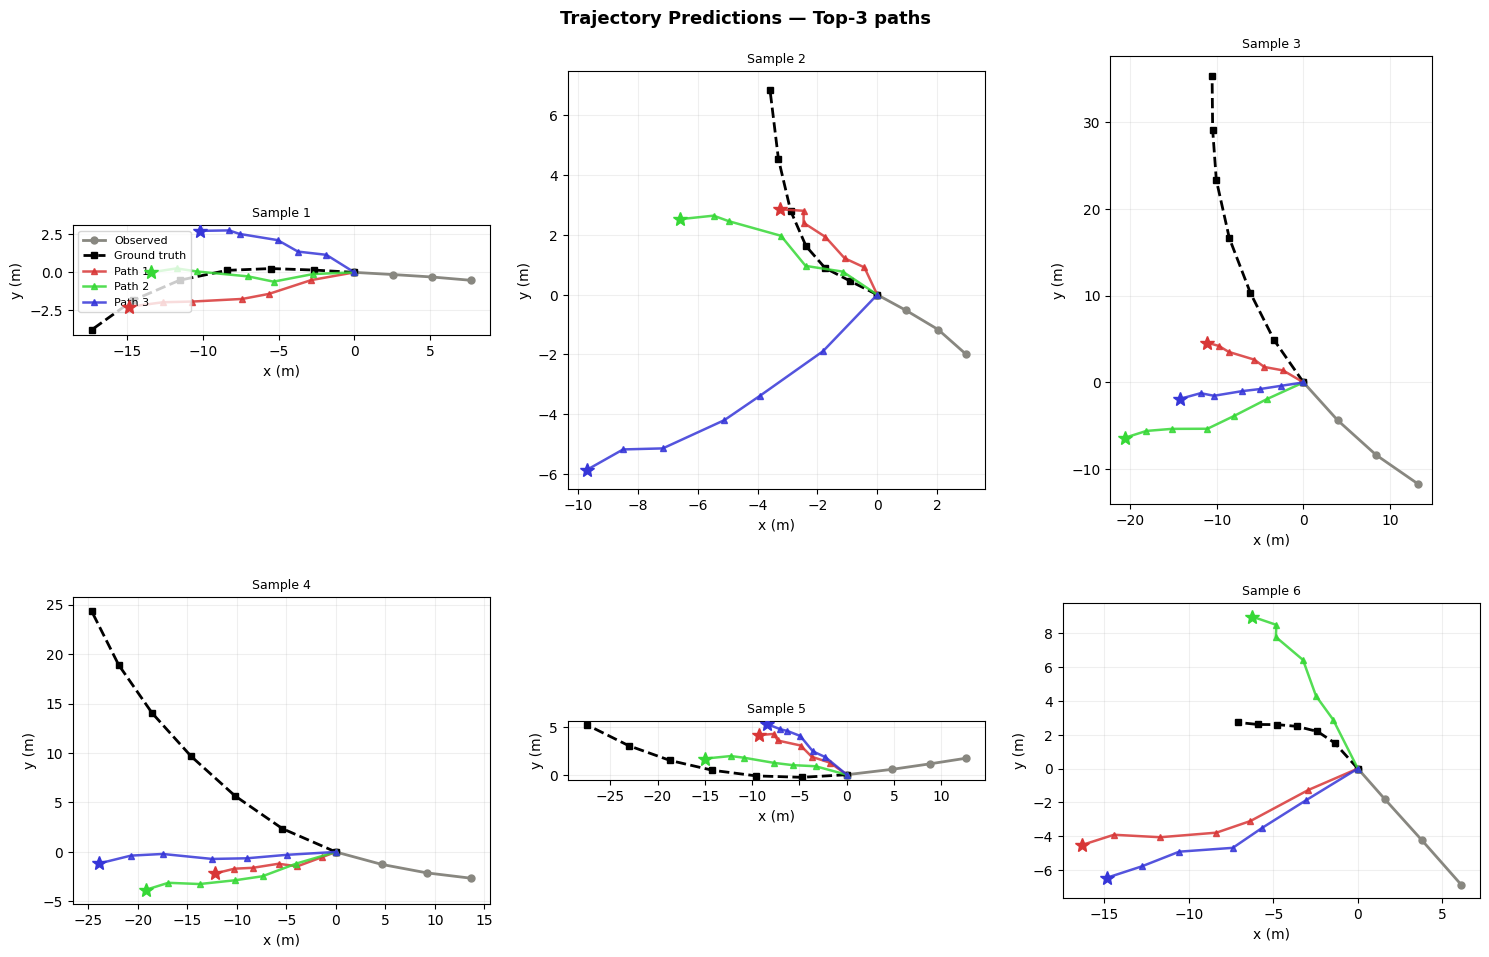

Saved: /content/drive/MyDrive/content/trajectory_predictions.png


In [ ]:
def visualise_predictions(model, dataset, num_samples=6, K=3):
    """
    Visualise K predicted trajectories vs ground truth for random samples.
    Works with any num_samples by computing grid dimensions dynamically.
    """
    was_training = model.training
    model.eval()

    # ✓ Dynamic grid — works for any num_samples
    ncols    = 3
    nrows    = math.ceil(num_samples / ncols)
    indices  = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    # ✓ Generate enough colours for any K via HSV spread
    import colorsys
    def k_colors(K):
        return [
            '#%02x%02x%02x' % tuple(int(c*255) for c in colorsys.hsv_to_rgb(i/K, 0.75, 0.85))
            for i in range(K)
        ]
    colors_pred = k_colors(K)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f'Trajectory Predictions — Top-{K} paths', fontsize=13, fontweight='bold')

    for plot_idx, ds_idx in enumerate(indices):
        sample = dataset[ds_idx]

        # ✓ Use model.forward() — no manual encoder duplication
        batch  = {k: v.unsqueeze(0) for k, v in sample.items()}
        with torch.no_grad():
            pred_k = model(batch, K=K)                      # (1, K, T, 2)
        pred_k = pred_k[0].cpu().numpy()                    # (K, T, 2)

        obs_xy = sample['obs_xy'].numpy()                   # (obs_len, 2)
        fut_xy = sample['future_xy'].numpy()                # (pred_len, 2)

        # ✓ Centre all coordinates on the last observed point
        #   so every plot fills its axes regardless of global position
        origin = obs_xy[-1].copy()
        obs_c  = obs_xy  - origin
        fut_c  = fut_xy  - origin
        pred_c = pred_k  - origin                           # (K, T, 2)

        ax = axes[plot_idx]

        # Observed trajectory
        ax.plot(obs_c[:, 0], obs_c[:, 1],
                'o-', color='#888780', linewidth=2, markersize=5,
                label='Observed', zorder=3)

        # Ground truth future (connected from last obs point)
        full_gt = np.vstack([obs_c[-1:], fut_c])
        ax.plot(full_gt[:, 0], full_gt[:, 1],
                's--', color='black', linewidth=2, markersize=5,
                label='Ground truth', zorder=4)

        # K predictions
        for k in range(K):
            full_pred = np.vstack([obs_c[-1:], pred_c[k]])
            ax.plot(full_pred[:, 0], full_pred[:, 1],
                    '^-', color=colors_pred[k], linewidth=1.8,
                    markersize=4, alpha=0.85,
                    label=f'Path {k+1}', zorder=5)
            # Mark predicted endpoint
            ax.plot(pred_c[k, -1, 0], pred_c[k, -1, 1],
                    '*', color=colors_pred[k], markersize=10, zorder=6)

        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)
        ax.set_xlabel('x (m)')
        ax.set_ylabel('y (m)')
        ax.set_title(f'Sample {plot_idx + 1}', fontsize=9)
        if plot_idx == 0:
            ax.legend(loc='upper left', fontsize=8)

    # Hide any unused subplot panels
    for i in range(len(indices), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()

    # ✓ Save to Drive so it persists after session ends
    save_path = Path(CFG['save_dir']).parent / 'trajectory_predictions.png'
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

    # ✓ Restore training mode
    if was_training:
        model.train()


# ✓ val_ds is a TrajectoryDataset directly — no .dataset needed
visualise_predictions(model, val_ds, num_samples=6, K=CFG['K'])

## Cell 14 — Inference Demo (single scene)

In [ ]:
def predict_single(model, sample_dict, K=3):
    """
    Run inference on a single sample dict.
    Returns predicted_xy: (K, pred_len, 2) — K trajectory paths in metres.
    """
    was_training = model.training
    model.eval()

    # ✓ Exclude future_xy — inference should not see ground truth
    inference_keys = ['obs_vel', 'obs_xy', 'social_obs', 'social_mask']
    batch = {
        k: sample_dict[k].unsqueeze(0).to(device)
        for k in inference_keys
        if isinstance(sample_dict.get(k), torch.Tensor)
    }

    with torch.no_grad():
        # ✓ Use model.forward() — no manual encoder duplication
        pred_k = model(batch, K=K)              # (1, K, pred_len, 2)

    if was_training:
        model.train()

    return pred_k[0].cpu().numpy()              # (K, pred_len, 2)


# ── Example inference ─────────────────────────────────────────────────────────
# ✓ val_ds is TrajectoryDataset directly — no .dataset needed
test_sample  = val_ds[0]
predictions  = predict_single(model, test_sample, K=CFG['K'])

print(f'Input:  {CFG["obs_len"]} timesteps '
      f'({CFG["obs_len"]/2:.0f}s of observed history)')
print(f'Output: {CFG["K"]} predicted paths, '
      f'each {CFG["pred_len"]} timesteps ({CFG["pred_len"]/2:.0f}s ahead)')
print()

for k, path in enumerate(predictions):
    final      = path[-1]
    total_dist = np.sum(np.linalg.norm(np.diff(path, axis=0), axis=1))
    print(f'Path {k+1}: '
          f'final position = ({final[0]:.2f} m, {final[1]:.2f} m) | '
          f'total distance = {total_dist:.2f} m')

Input:  4 timesteps (2s of observed history)
Output: 3 predicted paths, each 6 timesteps (3s ahead)

Path 1: final position = (24.64 m, -29.66 m) | total distance = 19.16 m
Path 2: final position = (29.89 m, -21.77 m) | total distance = 13.60 m
Path 3: final position = (33.95 m, -18.76 m) | total distance = 9.66 m


## Cell 15 — Save Everything for Submission

In [ ]:
import json

# ── Guard: ensure Cell 12 metrics are available ───────────────────────────────
if 'final_ade' not in dir() or 'final_fde' not in dir():
    raise RuntimeError(
        'final_ade / final_fde not defined. Run Cell 12 first.'
    )
if 'checkpoint' not in dir():
    raise RuntimeError(
        'checkpoint not defined. Run Cell 12 first.'
    )

# ── Build results dict with only JSON-serialisable values ────────────────────
def make_serialisable(obj):
    """Recursively convert Path and other non-JSON types to str."""
    if isinstance(obj, dict):
        return {k: make_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, Path):
        return str(obj)
    return obj

results = {
    'model':         'SocialTransformer+CVAE',
    'dataset':       'nuScenes-mini',
    'obs_seconds':   CFG['obs_len']  / 2,
    'pred_seconds':  CFG['pred_len'] / 2,
    'K':             CFG['K'],
    f'minADE@{CFG["K"]}': round(float(final_ade), 4),
    f'minFDE@{CFG["K"]}': round(float(final_fde), 4),
    'total_params':  sum(p.numel() for p in model.parameters()),
    'best_epoch':    checkpoint['epoch'],
    'vel_std':       round(float(model.vel_std.item()), 6),
    'config':        make_serialisable(CFG),
}

# ── Save results.json to Drive (persists after session ends) ─────────────────
results_path = Path(CFG['save_dir']).parent / 'results.json'
results_path.parent.mkdir(parents=True, exist_ok=True)

with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

# ── Canonical file locations (all on Drive) ───────────────────────────────────
drive_base = Path(CFG['save_dir']).parent
files_saved = {
    'Model weights':    str(Path(CFG['best_model'])),
    'Training curves':  str(drive_base / 'training_curves.png'),
    'Predictions plot': str(drive_base / 'trajectory_predictions.png'),
    'Results JSON':     str(results_path),
}

print('Files saved to Google Drive:')
for label, path in files_saved.items():
    exists = '✓' if Path(path).exists() else '✗ NOT FOUND'
    print(f'  [{exists}] {label}: {path}')

print()
print('Download with:')
print('  from google.colab import files')
for path in files_saved.values():
    print(f'  files.download("{path}")')

# ── Final summary ─────────────────────────────────────────────────────────────
print()
print('=' * 50)
print('FINAL RESULTS SUMMARY')
print('=' * 50)
for k, v in results.items():
    if k != 'config':
        print(f'  {k}: {v}')

Files saved to Google Drive:
  [✓] Model weights: /content/drive/MyDrive/content/checkpoints/best_model.pt
  [✓] Training curves: /content/drive/MyDrive/content/training_curves.png
  [✓] Predictions plot: /content/drive/MyDrive/content/trajectory_predictions.png
  [✓] Results JSON: /content/drive/MyDrive/content/results.json

Download with:
  from google.colab import files
  files.download("/content/drive/MyDrive/content/checkpoints/best_model.pt")
  files.download("/content/drive/MyDrive/content/training_curves.png")
  files.download("/content/drive/MyDrive/content/trajectory_predictions.png")
  files.download("/content/drive/MyDrive/content/results.json")

FINAL RESULTS SUMMARY
  model: SocialTransformer+CVAE
  dataset: nuScenes-mini
  obs_seconds: 2.0
  pred_seconds: 3.0
  K: 3
  minADE@3: 4.8475
  minFDE@3: 8.1327
  total_params: 668684
  best_epoch: 1
  vel_std: 1.871905


In [ ]:
print(f'Train windows: {len(train_windows)}')
print(f'Val windows:   {len(val_windows)}')
print(f'Train batches: {len(train_loader)}')
print()
print('First few training loss values:')
for i, v in enumerate(history['train_loss'][:10]):
    print(f'  Epoch {i+1}: {v:.4f}')
print()
print('Val ADE history:')
for i, v in enumerate(history["val_ade"]):
    print(f'  Val checkpoint {i+1}: {v:.4f}')

Train windows: 2189
Val windows:   1362
Train batches: 35

First few training loss values:
  Epoch 1: nan
  Epoch 2: nan
  Epoch 3: nan
  Epoch 4: -inf
  Epoch 5: nan
  Epoch 6: -inf
  Epoch 7: nan
  Epoch 8: 69.5053
  Epoch 9: 70.0215
  Epoch 10: 67.4145

Val ADE history:
  Val checkpoint 1: 4.7303
  Val checkpoint 2: 50.4815
  Val checkpoint 3: 55.0137
  Val checkpoint 4: 41.8320
  Val checkpoint 5: 35.7067
  Val checkpoint 6: 31.6156
  Val checkpoint 7: 28.5119
  Val checkpoint 8: 28.4474
  Val checkpoint 9: 28.8828
  Val checkpoint 10: 28.0892
  Val checkpoint 11: 27.5529
  Val checkpoint 12: 25.4222
  Val checkpoint 13: 26.1990
  Val checkpoint 14: 25.8577
  Val checkpoint 15: 23.1453
  Val checkpoint 16: 26.9176
  Val checkpoint 17: 25.3882
  Val checkpoint 18: 26.4143
  Val checkpoint 19: 25.1140
  Val checkpoint 20: 27.6106
  Val checkpoint 21: 26.6609


In [ ]:
# % of predictions within a distance threshold
threshold_m = 2.0   # 2 metre tolerance

close_count = 0
total = 0

model.eval()
with torch.no_grad():
    for batch in val_loader:
        gt_xy  = batch['future_xy'].to(device)   # (B, T, 2)
        pred_k = model(batch, K=CFG['K'])         # (B, K, T, 2)
        B, K, T, _ = pred_k.shape

        # Final displacement for each K
        fde_k = torch.norm(
            pred_k[:, :, -1, :] - gt_xy[:, -1, :].unsqueeze(1),
            dim=-1
        )   # (B, K)

        min_fde = fde_k.min(dim=1).values         # (B,)
        close_count += (min_fde < threshold_m).sum().item()
        total       += B

pct = 100 * close_count / total
print(f'% predictions within {threshold_m}m at final step: {pct:.1f}%')

% predictions within 2.0m at final step: 8.2%


In [ ]:
#missing rate

In [ ]:
@torch.no_grad()
def miss_rate(model, loader, threshold=2.0, K=3):
    """
    % of predictions where the BEST of K paths still misses
    the final position by more than `threshold` metres.
    Lower is better. 0% = perfect.
    """
    missed = 0
    total  = 0

    was_training = model.training
    model.eval()

    for batch in loader:
        gt_xy  = batch['future_xy'].to(device)      # (B, T, 2)
        pred_k = model(batch, K=K)                  # (B, K, T, 2)
        B      = gt_xy.shape[0]

        fde_k   = torch.norm(
            pred_k[:, :, -1, :] - gt_xy[:, -1, :].unsqueeze(1),
            dim=-1
        )                                           # (B, K)
        min_fde = fde_k.min(dim=1).values           # (B,)

        missed += (min_fde > threshold).sum().item()
        total  += B

    if was_training:
        model.train()

    hit_rate  = 100 * (1 - missed / total)
    miss_rate = 100 * missed / total
    return hit_rate, miss_rate


hit, miss = miss_rate(model, val_loader, threshold=2.0, K=CFG['K'])
print(f'Hit  Rate (within 2m): {hit:.1f}%   ← "accuracy"')
print(f'Miss Rate (beyond 2m): {miss:.1f}%')

Hit  Rate (within 2m): 8.6%   ← "accuracy"
Miss Rate (beyond 2m): 91.4%


In [ ]:
@torch.no_grad()
def threshold_accuracy(model, loader, thresholds=[0.5, 1.0, 2.0, 4.0], K=3):
    """
    Hit rate at multiple distance thresholds.
    Gives a full picture of how accurate predictions are.
    """
    was_training = model.training
    model.eval()

    all_min_fde = []
    all_min_ade = []

    for batch in loader:
        gt_xy  = batch['future_xy'].to(device)
        pred_k = model(batch, K=K)
        B, _, T, _ = pred_k.shape

        gt_exp  = gt_xy.unsqueeze(1).expand_as(pred_k)

        # minADE
        ade_k       = torch.norm(pred_k - gt_exp, dim=-1).mean(dim=2)  # (B, K)
        all_min_ade.extend(ade_k.min(dim=1).values.cpu().tolist())

        # minFDE
        fde_k       = torch.norm(
            pred_k[:, :, -1, :] - gt_xy[:, -1, :].unsqueeze(1),
            dim=-1
        )                                                               # (B, K)
        all_min_fde.extend(fde_k.min(dim=1).values.cpu().tolist())

    if was_training:
        model.train()

    all_min_fde = np.array(all_min_fde)
    all_min_ade = np.array(all_min_ade)

    print(f'{"Threshold":<12} {"FDE Hit Rate":>14} {"ADE Hit Rate":>14}')
    print('-' * 42)
    for t in thresholds:
        fde_acc = 100 * (all_min_fde < t).mean()
        ade_acc = 100 * (all_min_ade < t).mean()
        print(f'{t:<12.1f} {fde_acc:>13.1f}% {ade_acc:>13.1f}%')

    print()
    print(f'Mean minADE@{K}: {all_min_ade.mean():.4f} m')
    print(f'Mean minFDE@{K}: {all_min_fde.mean():.4f} m')


threshold_accuracy(model, val_loader, K=CFG['K'])

Threshold      FDE Hit Rate   ADE Hit Rate
------------------------------------------
0.5                    0.5%           0.1%
1.0                    2.3%           2.4%
2.0                    8.7%          16.9%
4.0                   26.4%          49.6%

Mean minADE@3: 4.8338 m
Mean minFDE@3: 8.0632 m


In [ ]:
@torch.no_grad()
def full_accuracy_report(model, loader, K=3):
    was_training = model.training
    model.eval()

    all_min_fde = []

    for batch in loader:
        gt_xy  = batch['future_xy'].to(device)
        pred_k = model(batch, K=K)
        fde_k  = torch.norm(
            pred_k[:, :, -1, :] - gt_xy[:, -1, :].unsqueeze(1),
            dim=-1
        )
        all_min_fde.extend(fde_k.min(dim=1).values.cpu().tolist())

    if was_training:
        model.train()

    arr = np.array(all_min_fde)

    print('=' * 40)
    print(f'  MODEL ACCURACY REPORT  (K={K})')
    print('=' * 40)
    print(f'  Samples evaluated : {len(arr)}')
    print(f'  Mean final error  : {arr.mean():.2f} m')
    print(f'  Median final error: {np.median(arr):.2f} m')
    print()
    print(f'  Within 1m  : {100*(arr<1.0).mean():.1f}%  (excellent)')
    print(f'  Within 2m  : {100*(arr<2.0).mean():.1f}%  (good)')
    print(f'  Within 4m  : {100*(arr<4.0).mean():.1f}%  (acceptable)')
    print(f'  Beyond 4m  : {100*(arr>=4.0).mean():.1f}%  (miss)')
    print('=' * 40)


full_accuracy_report(model, val_loader, K=CFG['K'])

  MODEL ACCURACY REPORT  (K=3)
  Samples evaluated : 1362
  Mean final error  : 8.05 m
  Median final error: 6.45 m

  Within 1m  : 2.1%  (excellent)
  Within 2m  : 8.0%  (good)
  Within 4m  : 27.9%  (acceptable)
  Beyond 4m  : 72.1%  (miss)
